In [5]:
#!/usr/bin/env python3
"""
BayesBay + hvswdpy example: joint inversion of Rayleigh phase-velocity dispersion
and H/V spectral ratio (HVSR) using a transdimensional 1D Vs model (Voronoi1D).

Requirements:
  - bayesbay >= 0.3
  - numpy, matplotlib
  - your forward solver importable as `import hvswdpy as hv`

Notes:
  * Units: this script works in SI (m, s). Ensure your priors and forward model
    use consistent units. If you use km/s and km, convert accordingly.
  * Model: Vs(z) is unknown & piecewise-constant on a Voronoi1D tessellation.
    Vp and rho are mapped from Vs via simple empirical relations (tweak as needed).
  * Transdimensionality: the number of Voronoi sites (layers) is inferred
    between n_dimensions_min and n_dimensions_max.
  * Hierarchical noise: standard deviations for both datasets are treated as unknowns.

Author: Shihao Yuan (syuan@mines.edu)
"""

from __future__ import annotations
import warnings, numpy as np
warnings.filterwarnings("ignore", category=DeprecationWarning, module="bayesbay")
np.seterr(all="ignore")  # only if you see numeric warnings
import matplotlib.pyplot as plt
import bayesbay as bb
from bayesbay.discretization import Voronoi1D

import matplotlib.pyplot as plt

# Ensure the project root (which contains `hvswdpy.py`) is importable when running from the notebook folder
import sys, os
from pathlib import Path
try:
    import hvswdpy as hv
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
    import hvswdpy as hv



In [69]:
# --- USER INPUTS -----------------------------------------------------------------
# Observations (replace with your data):
# Frequencies for dispersion (Hz) and HV (Hz)
freq_disp = np.geomspace(0.1, 20.0, 50)   # example
freq_hv   = np.geomspace(0.1, 20.0, 50)   # example

# Choose a reference model: layers (top to bottom) + halfspace
# vp_ref, vs_ref, rho_ref have length nlayers; thickness_ref has length nlayers-1
vp_ref  = np.array([1000., 2000. ])
vs_ref  = np.array([500., 1000.])
rho_ref = np.array([1000., 3000.])
th_ref  = np.array([120. ])  # one layer over halfspace → one thickness

# Choose which Rayleigh mode to fit (0 = fundamental). You can also pass a list
RAY_MODE = 0

# Generate synthetic HV observations
hv_obs, _ = hv.hv(
    frequencies_hz=freq_hv,
    vp=vp_ref, vs=vs_ref, rho=rho_ref, thickness=th_ref,
    n_rayleigh_modes=3, n_love_modes=3, precision_percent=1.0, nks=0,
)

# Generate synthetic Rayleigh dispersion observations
disp = hv.dispersion(
    frequencies_hz=freq_disp,
    vp=vp_ref, vs=vs_ref, rho=rho_ref, thickness=th_ref,
    n_rayleigh_modes=RAY_MODE+1, n_love_modes=0, precision_percent=1.0,
)
valid_mask = (disp.rayleigh_valid[:, RAY_MODE] != 0)
c_obs_full = 1.0 / disp.rayleigh_slowness[:, RAY_MODE]

# Keep only valid points (recommended for stability)
freq_disp = freq_disp[valid_mask]
c_obs     = c_obs_full[valid_mask]
valid_disp = np.ones_like(c_obs, dtype=bool)


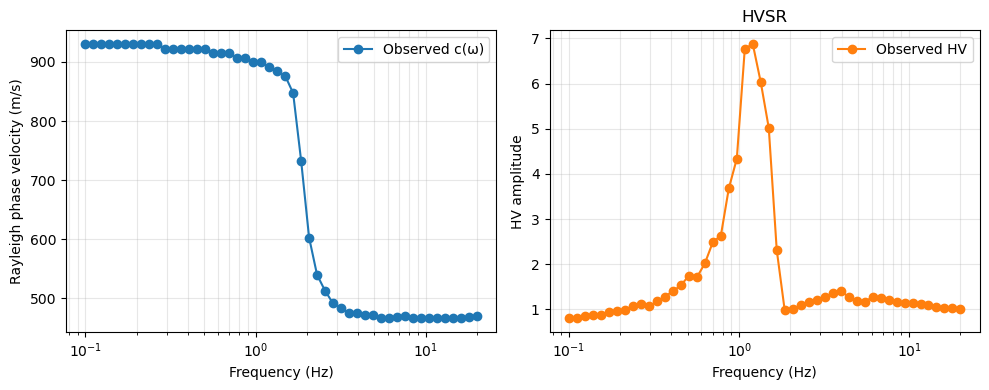

In [72]:

# Prepare dispersion data (respect valid mask if present)
if 'valid_disp' in globals() and valid_disp is not None and np.size(valid_disp) == np.size(c_obs):
    fd = freq_disp[valid_disp]
    cd = c_obs[valid_disp]
else:
    fd, cd = freq_disp, c_obs

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Observed Rayleigh dispersion
ax[0].semilogx(fd, cd, 'o-', label='Observed c(ω)')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Rayleigh phase velocity (m/s)')
# ax[0].set_title(f'Dispersion (mode {RAY_MODE if \"RAY_MODE\" in globals() else 0})')
ax[0].grid(True, which='both', alpha=0.3)
ax[0].legend()

# Observed HVSR
ax[1].semilogx(freq_hv, hv_obs, 'o-', color='C1', label='Observed HV')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('HV amplitude')
ax[1].set_title('HVSR')
ax[1].grid(True, which='both', alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [45]:
disp.rayleigh_valid.shape

(50, 1)

In [ ]:
# Simple empirical Vp/Vs and rho(Vp) maps (change to what you prefer)
VP_VS = 1.77
RHO_FROM_VP = lambda vp: 1800.0 + 0.31 * vp  # kg/m^3, crude; adjust!

# Vs prior bounds (m/s) versus depth control points (m)
# Provide vectors of (vmin, vmax) at specific depths; values are interpolated in between
prior_depths = np.array([0.0, 30.0, 100.0, 300.0])
prior_vmin   = np.array([150.0, 250.0, 400.0, 700.0])
prior_vmax   = np.array([800.0, 1200.0, 1800.0, 2500.0])

# Transdimensional controls
NMIN, NMAX = 1, 3                    # allowed number of Voronoi sites (layers)
VS_PERTURB_STD = 100.0                # m/s (proposal std for Vs)
SITE_PERTURB_STD = 10.0               # m (proposal std for site positions)

# Inference controls
NCHAINS = 8
NITER = 80_000
BURN  = 20_000
SAVE_EVERY = 100

# --- IMPORT YOUR FORWARD SOLVER ---------------------------------------------------
# Expecting API compatible with your example message:
# hv.dispersion(...).rayleigh_slowness  -> array of shape (nf, nm)
# hv.hv(...) -> vector of HVSR values per frequency


# --- PRIORS ----------------------------------------------------------------------
# Depth-dependent uniform prior for Vs using control-point parameterization
vs_prior = bb.prior.UniformPrior(
    name="vs",
    vmin=prior_vmin.tolist(),
    vmax=prior_vmax.tolist(),
    position=prior_depths.tolist(),
    perturb_std=VS_PERTURB_STD,
)

# Custom initializer to encourage monotonic increase with depth (optional)
def initialize_vs(param, positions=None):
    vmin, vmax = param.get_vmin_vmax(positions)
    raw = np.random.uniform(vmin, vmax, positions.size)
    return np.maximum.accumulate(np.sort(raw))

vs_prior.set_custom_initialize(initialize_vs)

# Transdimensional 1D Voronoi for the depth axis; bounds define search domain
vor = Voronoi1D(
    name="voronoi",
    vmin=0.0,
    vmax=300.0,  # search depth (m)
    perturb_std=SITE_PERTURB_STD,
    n_dimensions=None,
    n_dimensions_min=NMIN,
    n_dimensions_max=NMAX,
    parameters=[vs_prior],
    birth_from="neighbour",
)

parameterization = bb.parameterization.Parameterization(vor)

# --- FORWARD FUNCTIONS ------------------------------------------------------------
# All forward mappers take the current state and return a data vector prediction

def forward_rayleigh(state):
    v = state["voronoi"]
    z_sites = v["discretization"]                 # Voronoi site positions (depths)
    thickness_full = Voronoi1D.compute_cell_extents(z_sites)  # length = nlayers
    vs = v["vs"]                                   # Vs at sites (m/s)
    vp = vs * VP_VS
    rho = RHO_FROM_VP(vp)

    # Fortran expects thickness array of length nlayers-1 (excluding halfspace)
    thickness = thickness_full[:-1]

    out = hv.dispersion(
        frequencies_hz=freq_disp,
        vp=vp, vs=vs, rho=rho, thickness=thickness,
        n_rayleigh_modes=max(RAY_MODE+1, 1),
        n_love_modes=0,
        precision_percent=1.0,
    )

    sl = out.rayleigh_slowness   # shape (nf, nm)
    va = out.rayleigh_valid      # shape (nf, nm) nonzero for valid

    sl_mode = sl[:, RAY_MODE]
    va_mode = (va[:, RAY_MODE] != 0)

    if not np.all(va_mode):
        idx = np.where(va_mode)[0]
        if idx.size > 0:
            sl_mode = np.interp(np.arange(sl_mode.size), idx, sl_mode[va_mode])
        else:
            sl_mode[:] = np.nanmedian(sl_mode) if np.isfinite(sl_mode).any() else 1.0/1000.0

    c_pred = 1.0 / sl_mode
    return c_pred


def forward_hvsr(state):
    v = state["voronoi"]
    z_sites = v["discretization"]
    thickness_full = Voronoi1D.compute_cell_extents(z_sites)
    vs = v["vs"]
    vp = vs * VP_VS
    rho = RHO_FROM_VP(vp)

    hv_pred, _status = hv.hv(
        frequencies_hz=freq_hv,
        vp=vp, vs=vs, rho=rho, thickness=thickness_full[:-1],
        n_rayleigh_modes=max(RAY_MODE+1, 1),
        n_love_modes=0,
        precision_percent=1.0,
        nks=0,
    )
    return hv_pred

# --- TARGETS & JOINT LIKELIHOOD --------------------------------------------------
# Hierarchical noise: let BayesBay infer std for both datasets

target_disp = bb.Target(
    name="rayleigh",
    dobs=c_obs.astype(float),
    std_min=0.5,   # m/s, tune for your data
    std_max=200.0,
    std_perturb_std=1.0,
)

target_hv = bb.Target(
    name="hvsr",
    dobs=hv_obs.astype(float),
    std_min=0.02,
    std_max=1.0,
    std_perturb_std=0.01,
)

log_likelihood = bb.LogLikelihood(
    targets=[target_disp, target_hv],
    fwd_functions=[forward_rayleigh, forward_hvsr],
)

# --- RUN INVERSION ---------------------------------------------------------------
inv = bb.BayesianInversion(
    parameterization=parameterization,
    log_likelihood=log_likelihood,
    n_chains=NCHAINS,
)

inv.run(
    sampler=None,                # defaults are fine; customize if needed
    n_iterations=NITER,
    burnin_iterations=BURN,
    save_every=SAVE_EVERY,
    verbose=True,
)

# --- POSTERIOR QUICKLOOK ---------------------------------------------------------
# Extract stacked posterior mean Vs(z) and credible intervals

def summarize_vs(chain):
    # Sample a regular depth grid and interpolate each state's Vs onto it
    z = np.linspace(0, 300, 151)
    vs_samples = []
    for state in chain.states:
        v = state["voronoi"]
        z_sites = v["discretization"]
        vs_sites = v["vs"]
        # piecewise-constant between Voronoi cell boundaries
        edges = Voronoi1D.compute_cell_boundaries(z_sites)
        zc = 0.5*(edges[:-1] + edges[1:])
        vs_interp = np.interp(z, zc, vs_sites, left=vs_sites[0], right=vs_sites[-1])
        vs_samples.append(vs_interp)
    vs_samples = np.asarray(vs_samples)
    return z, np.nanmean(vs_samples, axis=0), np.nanpercentile(vs_samples, [5,95], axis=0)

# Use the coldest chain
chain0 = inv.chains[0]
chain0.print_statistics()

z, vs_mean, (vs_p05, vs_p95) = summarize_vs(chain0)

plt.figure(figsize=(4,6))
plt.fill_betweenx(z, vs_p05, vs_p95, alpha=0.3, label='90% CI')
plt.plot(vs_mean, z, lw=2, label='Posterior mean')
plt.gca().invert_yaxis()
plt.xlabel('Vs (m/s)')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Target(name='hvsr, dobs=ndarray of shape (40,), is_hierarchical=True, noise_is_correlated=False, std_min=0.02, std_max=1.0, std_perturb_std=0.01)